# Assignment 01 — Intelligent System Development
## Dự đoán giá nhà tại Việt Nam bằng Machine Learning và định hướng triển khai Mobile

**Dataset:** House Price Prediction Dataset Vietnam - 2024  
**Nguồn:** Kaggle — Nguyen Tien Nhan  
**Bài toán:** Regression — dự đoán `Price` (tỷ VND) từ các thuộc tính của bất động sản.

> Notebook này được thiết kế bám theo cấu trúc Assignment 01: **Understand → Represent → Learn → Experiment → Apply**.  
> Phần triển khai Mobile được đánh dấu **DEFER** theo yêu cầu; notebook vẫn chuẩn bị bước lưu mô hình và mô tả kiến trúc để có thể tích hợp ở giai đoạn sau.

## 1. System and Problem Definition

### Phát biểu bài toán
Cho một bất động sản chưa quan sát, hệ thống nhận các đặc trưng về vị trí/mô tả, diện tích và đặc điểm vật lý của căn nhà, biểu diễn chúng thành vector đặc trưng và dự đoán **giá nhà (`Price`)** bằng một mô hình Machine Learning truyền thống.

### Intelligent System
- **Input:** thông tin căn nhà.
- **Representation:** vector gồm biến số + biến phân loại được mã hóa One-Hot.
- **Learning:** học quan hệ giữa đặc trưng và giá từ dữ liệu huấn luyện.
- **Decision/Prediction:** giá dự đoán.
- **Application:** giao diện nhập thông tin → tiền xử lý → mô hình → giá dự đoán.

Điều này phù hợp với yêu cầu của Assignment 01: hệ thống phải thể hiện đầy đủ **data + representation + model + application**, không chỉ gọi `model.fit()`.


## 2. Intelligent System Diagram

```text
┌─────────────────────┐
│ User / House data   │
│ Area, rooms, floors │
│ direction, legal... │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Feature             │
│ Representation      │
│ Numeric + One-Hot   │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Preprocessing       │
│ Imputation/Scaling  │
│ Encoding            │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Traditional ML      │
│ 5 regression models │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Prediction          │
│ House price (VND bn)│
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Application / Mobile│
│ (DEFER)             │
└─────────────────────┘
```


## 3. Dataset Source

Dataset được chọn theo yêu cầu sử dụng dữ liệu thực từ Kaggle.

**Kaggle:** https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024

Theo Data Card, dữ liệu gồm các thuộc tính như `Address`, `Area`, `Frontage`, `Access Road`, `House Direction`, `Balcony Direction`, `Floors`, `Bedrooms`, `Bathrooms`, `Legal Status`, `Furniture State` và `Price`. `Price` được mô tả theo đơn vị **tỷ đồng (billion VND)**.

**Lưu ý:** `Address` là trường văn bản có độ phân biệt cao; trong notebook này nó được loại khỏi vector đầu vào cơ bản để tránh One-Hot toàn bộ địa chỉ. Nếu muốn nghiên cứu thông tin địa lý, có thể trích xuất `City/District/Ward` thành các đặc trưng có cấu trúc ở một thí nghiệm riêng.


In [1]:
# 4. Environment & Imports
import sys
import platform
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Python:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__)


Python: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Platform: Windows-11-10.0.26100-SP0
pandas: 3.0.3


## 5. Load Data

Đường dẫn được đặt đúng theo file người dùng cung cấp. Khi chạy trên máy Windows, notebook sẽ đọc trực tiếp file CSV tại đường dẫn này.

Nếu notebook được chuyển sang máy khác, chỉ cần thay `DATA_PATH`.


In [2]:
# Đường dẫn dataset theo yêu cầu
DATA_PATH = r"D:\Tài Liệu\Năm 4\Kì 1\Phát triển hệ thống thông minh\DATA\vietnam_housing_dataset.csv"

if not __import__("os").path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy dataset tại:\n{DATA_PATH}\n\n"
        "Hãy đặt file vietnam_housing_dataset.csv đúng vị trí hoặc sửa DATA_PATH."
    )

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head())


Shape: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


## 6. Dataset Description & Feature/Target Analysis

Dataset là các quan sát bất động sản. Mỗi dòng tương ứng với một listing/observation.

- **Target:** `Price` — biến số cần dự đoán.
- **Task:** Regression.
- **Numerical features:** diện tích, mặt tiền, đường vào, số tầng, số phòng ngủ, số phòng tắm (tùy dữ liệu thực tế).
- **Categorical features:** hướng nhà, hướng ban công, tình trạng pháp lý, tình trạng nội thất.
- `Address` được giữ trong dataframe để kiểm tra dữ liệu nhưng **không đưa trực tiếp vào mô hình** trong pipeline cơ sở.


In [3]:
# Chuẩn hóa tên cột để xử lý linh hoạt
df = df_raw.copy()
df.columns = [str(c).strip() for c in df.columns]

print("Columns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Columns:
['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price']

Data types:


,dtype
Address,str
Area,float64
Frontage,float64
Access Road,float64
House direction,str
Balcony direction,str
Floors,float64
Bedrooms,float64
Bathrooms,float64
Legal status,str



Missing values:


,missing
Balcony direction,24983
House direction,21239
Furniture state,14119
Access Road,13297
Frontage,11564
Bathrooms,7074
Bedrooms,5162
Legal status,4506
Floors,3603
Area,0


In [4]:
# Tìm cột Price không phụ thuộc hoàn toàn vào viết hoa/thường
def find_column(columns, candidates):
    normalized = {str(c).strip().lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in normalized:
            return normalized[cand.lower()]
    for c in columns:
        cl = str(c).strip().lower()
        if any(cand.lower() in cl for cand in candidates):
            return c
    return None

TARGET = find_column(df.columns, ["Price", "price"])
if TARGET is None:
    raise ValueError("Không tìm thấy cột Price trong dataset.")

print("Target:", TARGET)


Target: Price


In [5]:
# Chuyển Price về numeric một cách an toàn.
# Hỗ trợ cả trường hợp dữ liệu đã là số và một số dạng chuỗi phổ biến của Việt Nam.
def parse_price(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)

    s = str(value).strip().lower()
    s = s.replace(",", "").replace(" ", "")

    # Loại ký hiệu tiền tệ nhưng giữ dấu chấm
    s = re.sub(r"(vnd|đ|₫)$", "", s)

    multiplier = 1.0
    if "tỷ" in s or "ty" in s:
        multiplier = 1.0
        s = s.replace("tỷ", "").replace("ty", "")
    elif "triệu" in s or "trieu" in s:
        multiplier = 0.001
        s = s.replace("triệu", "").replace("trieu", "")

    # Nếu có nhiều ký tự, lấy số đầu tiên
    match = re.search(r"-?\d+(?:\.\d+)?", s)
    if not match:
        return np.nan
    return float(match.group()) * multiplier

df[TARGET] = df[TARGET].apply(parse_price)

# Loại target không hợp lệ
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[TARGET]).copy()

print("Shape after target cleaning:", df.shape)
display(df[TARGET].describe().to_frame("Price"))


Shape after target cleaning: (30229, 12)


,Price
count,30229.000000
mean,5.872078
std,2.211877
min,1.000000
25%,4.200000
50%,5.900000
75%,7.500000
max,11.500000


## 7. Data Representation

Biểu diễn nội bộ của hệ thống:

\[
x_i = [x_{i1}, x_{i2}, \ldots, x_{id}]
\]

Trong đó:
- biến số → impute median → chuẩn hóa;
- biến phân loại → impute most frequent → One-Hot Encoding;
- target `Price` giữ ở dạng số.

Raw feature → encoded feature → model input là ba khái niệm khác nhau. Pipeline của scikit-learn đảm bảo cùng một phép biến đổi được dùng khi training và khi dự đoán dữ liệu mới.


In [6]:
# Xác định các feature theo tên thực tế của dataset
preferred_numeric = ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms"]
preferred_categorical = [
    "House Direction", "Balcony Direction",
    "Legal Status", "Furniture State"
]

numeric_cols = [c for c in preferred_numeric if c in df.columns and c != TARGET]
categorical_cols = [c for c in preferred_categorical if c in df.columns and c != TARGET]

# Fallback: nếu tên cột khác, tự nhận diện theo dtype,
# nhưng loại Address và các cột văn bản quá đặc thù.
if not numeric_cols:
    numeric_cols = [
        c for c in df.select_dtypes(include=np.number).columns
        if c != TARGET and c.lower() not in {"id"}
    ]

if not categorical_cols:
    categorical_cols = [
        c for c in df.select_dtypes(include=["object", "category"]).columns
        if c != TARGET and c.lower() != "address"
    ]

# Không dùng Address trực tiếp trong baseline representation
categorical_cols = [c for c in categorical_cols if c.lower() != "address"]

feature_cols = numeric_cols + categorical_cols

print("Numerical features:", numeric_cols)
print("Categorical features:", categorical_cols)
print("Total model features before encoding:", len(feature_cols))

display(pd.DataFrame({
    "Feature": feature_cols,
    "Type": ["Numerical"] * len(numeric_cols) + ["Categorical"] * len(categorical_cols),
    "Representation": (
        ["Median imputation + StandardScaler"] * len(numeric_cols)
        + ["Most-frequent imputation + One-Hot"] * len(categorical_cols)
    )
}))


Numerical features: ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
Categorical features: ['House direction', 'Balcony direction', 'Legal status', 'Furniture state']
Total model features before encoding: 10


,Feature,Type,Representation
0,Area,Numerical,Median imputation + StandardScaler
1,Frontage,Numerical,Median imputation + StandardScaler
2,Access Road,Numerical,Median imputation + StandardScaler
3,Floors,Numerical,Median imputation + StandardScaler
4,Bedrooms,Numerical,Median imputation + StandardScaler
5,Bathrooms,Numerical,Median imputation + StandardScaler
6,House direction,Categorical,Most-frequent imputation + One-Hot
7,Balcony direction,Categorical,Most-frequent imputation + One-Hot
8,Legal status,Categorical,Most-frequent imputation + One-Hot
9,Furniture state,Categorical,Most-frequent imputation + One-Hot


## 8. Exploratory Data Analysis — 3 Biểu đồ phân phối

Ba biểu đồ phân phối chính:
1. Phân phối **Price**;
2. Phân phối **Area**;
3. Phân phối **Bedrooms**.

Mục tiêu là quan sát độ lệch, giá trị cực đoan và đặc điểm của dữ liệu trước khi huấn luyện.


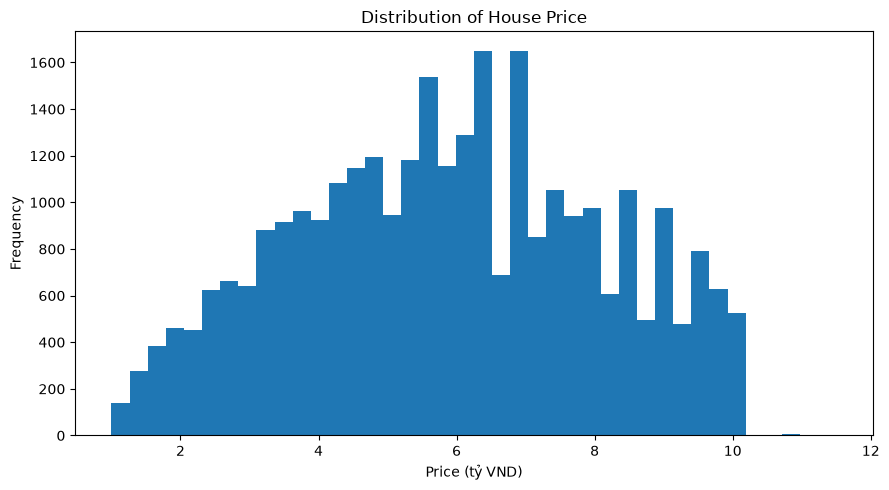

In [7]:
# Biểu đồ 1 — Phân phối giá nhà
plt.figure(figsize=(9, 5))
plt.hist(df[TARGET].dropna(), bins=40)
plt.xlabel("Price (tỷ VND)")
plt.ylabel("Frequency")
plt.title("Distribution of House Price")
plt.tight_layout()
plt.show()


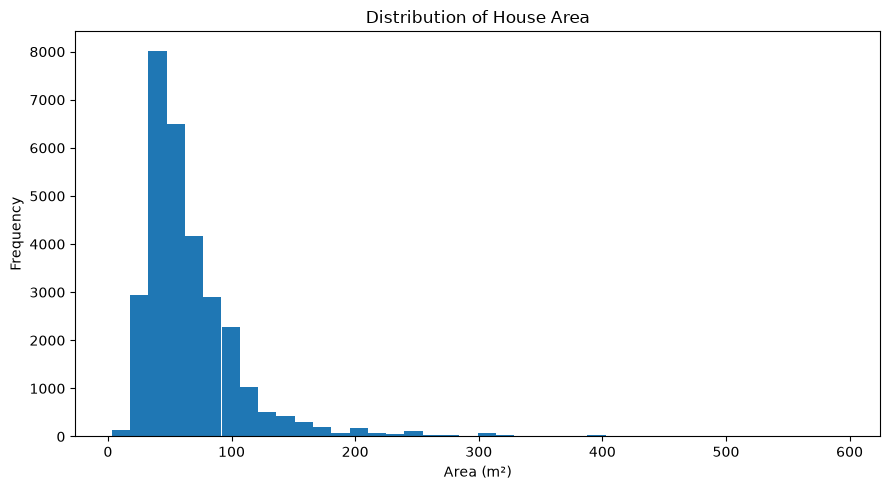

In [8]:
# Biểu đồ 2 — Phân phối diện tích
AREA_COL = find_column(df.columns, ["Area"])
if AREA_COL:
    area_numeric = pd.to_numeric(df[AREA_COL], errors="coerce")
    plt.figure(figsize=(9, 5))
    plt.hist(area_numeric.dropna(), bins=40)
    plt.xlabel("Area (m²)")
    plt.ylabel("Frequency")
    plt.title("Distribution of House Area")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy cột Area.")


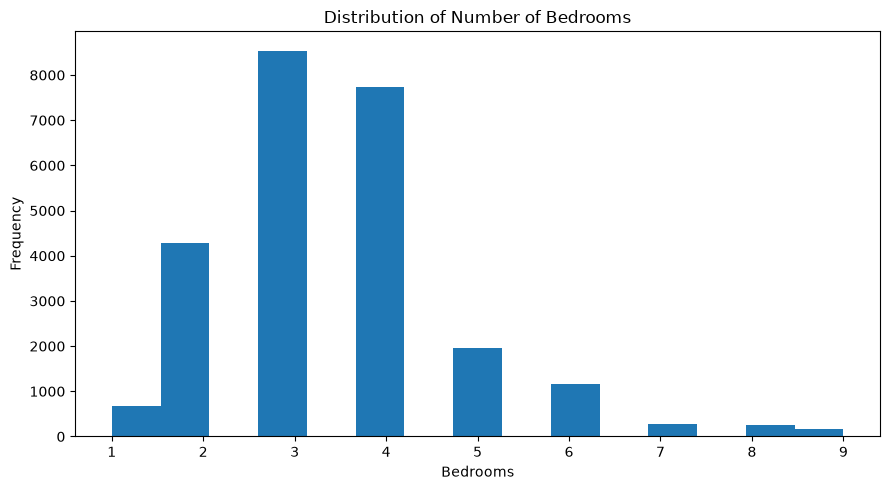

In [9]:
# Biểu đồ 3 — Phân phối số phòng ngủ
BED_COL = find_column(df.columns, ["Bedrooms", "Bedroom"])
if BED_COL:
    bed_numeric = pd.to_numeric(df[BED_COL], errors="coerce")
    plt.figure(figsize=(9, 5))
    plt.hist(bed_numeric.dropna(), bins=15)
    plt.xlabel("Bedrooms")
    plt.ylabel("Frequency")
    plt.title("Distribution of Number of Bedrooms")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy cột Bedrooms.")


## 9. Train/Test Split

Tách:
- **80% train:** dùng để học và thực hiện controlled experiments bằng cross-validation;
- **20% test:** giữ lại để đánh giá cuối cùng.

Test set không được dùng để chọn hyperparameter hay quyết định mô hình trong quá trình phát triển.


In [10]:
X = df[feature_cols].copy()
y = df[TARGET].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (24183, 10) (24183,)
Test : (6046, 10) (6046,)


## 10. Preprocessing Pipeline

`ColumnTransformer` giúp giữ đúng representation giữa training và inference.

- Numeric: median imputation → StandardScaler.
- Categorical: most-frequent imputation → OneHotEncoder.
- `handle_unknown="ignore"` giúp ứng dụng không lỗi khi user nhập một category chưa xuất hiện trong training.


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)


## 11. Baseline

Baseline dùng `DummyRegressor(strategy="mean")`: luôn dự đoán giá trung bình của tập train.

Mục đích: kiểm tra các mô hình học được quan hệ thực sự có cải thiện so với một chiến lược đơn giản hay không.


In [12]:
baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_metrics = {
    "MAE": mean_absolute_error(y_test, baseline_pred),
    "MSE": mean_squared_error(y_test, baseline_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, baseline_pred)),
    "R2": r2_score(y_test, baseline_pred),
    "MAPE": mean_absolute_percentage_error(y_test, baseline_pred) * 100
}

pd.DataFrame([baseline_metrics], index=["Baseline (Mean)"])


,MAE,MSE,RMSE,R2,MAPE
Baseline (Mean),1.843751,4.876003,2.208167,-0.000018,44.434949


# 12. Five Traditional ML Models

Năm mô hình hồi quy:
1. **Linear Regression** — mô hình tuyến tính, dễ giải thích.
2. **Ridge Regression** — tuyến tính + L2 regularization.
3. **Decision Tree Regressor** — chia không gian đặc trưng theo các nút.
4. **Random Forest Regressor** — kết hợp nhiều cây, giảm variance.
5. **Support Vector Regression (SVR)** — tối ưu hàm hồi quy với margin và kernel RBF.

Tất cả đều dùng **cùng representation và preprocessing** để so sánh công bằng.


In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "SVR": SVR(
        kernel="rbf",
        C=100.0,
        epsilon=0.05,
        gamma="scale"
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

print("Models:", list(pipelines.keys()))


Models: ['Linear Regression', 'Ridge', 'Decision Tree', 'Random Forest', 'SVR']


## 13. Evaluation — 5 độ đo

Vì đây là **regression**, sử dụng:
- **MAE** — sai số tuyệt đối trung bình, cùng đơn vị với Price.
- **MSE** — bình phương sai số, phạt mạnh lỗi lớn.
- **RMSE** — căn MSE, cùng đơn vị với Price.
- **R²** — mức độ giải thích biến thiên của target.
- **MAPE** — sai số phần trăm tuyệt đối trung bình.

Quy ước chọn mô hình chính: **RMSE thấp nhất** trên cross-validation của tập train; MAE/R²/MAPE dùng để kiểm tra tính nhất quán.


In [14]:
# 5-fold CV trên TRAIN — test set được giữ nguyên
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2",
    "MAPE": "neg_mean_absolute_percentage_error"
}

cv_results = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    mae = -scores["test_MAE"]
    mse = -scores["test_MSE"]
    rmse = np.sqrt(mse)
    r2 = scores["test_R2"]
    mape = -scores["test_MAPE"] * 100

    cv_results.append({
        "Model": name,
        "MAE_mean": mae.mean(),
        "MAE_std": mae.std(),
        "MSE_mean": mse.mean(),
        "RMSE_mean": rmse.mean(),
        "R2_mean": r2.mean(),
        "MAPE_mean_%": mape.mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("RMSE_mean")
display(cv_results_df.style.format({
    "MAE_mean": "{:.4f}",
    "MAE_std": "{:.4f}",
    "MSE_mean": "{:.4f}",
    "RMSE_mean": "{:.4f}",
    "R2_mean": "{:.4f}",
    "MAPE_mean_%": "{:.2f}"
}))


,Model,MAE_mean,MAE_std,MSE_mean,RMSE_mean,R2_mean,MAPE_mean_%
3,Random Forest,1.4451,0.0116,3.4478,1.8568,0.2958,32.42
2,Decision Tree,1.5141,0.0141,3.7205,1.9288,0.2400,34.12
4,SVR,1.5084,0.0166,3.7548,1.9376,0.2332,33.64
1,Ridge,1.6059,0.0133,3.8844,1.9708,0.2067,37.12
0,Linear Regression,1.6059,0.0133,3.8844,1.9708,0.2067,37.12


## 14. Experiment 1 — Model Comparison

**Câu hỏi thực nghiệm:** Với cùng dữ liệu, cùng preprocessing và cùng 5-fold CV, mô hình nào dự đoán giá nhà tốt nhất?

Tiêu chí chính: RMSE thấp nhất. Bảng trên là bằng chứng để chọn mô hình thay vì khẳng định “model X tốt hơn” chỉ dựa trên cảm tính.


In [16]:
best_model_name = cv_results_df.iloc[0]["Model"]
best_cv_rmse = cv_results_df.iloc[0]["RMSE_mean"]

print(f"Best model by CV RMSE: {best_model_name}")
print(f"Mean CV RMSE: {best_cv_rmse:.4f}")


Best model by CV RMSE: Random Forest
Mean CV RMSE: 1.8568


## 15. Experiment 2 — Hyperparameter Investigation

**Câu hỏi:** Với Random Forest, số lượng cây (`n_estimators`) có ảnh hưởng như thế nào?

So sánh `n_estimators = 50, 100, 200, 300` bằng 5-fold CV trên **train**. Không dùng test set để chọn hyperparameter.


In [17]:
rf_tuning = []
for n_trees in [50, 100, 200, 300]:
    rf_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n_trees,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    scores = cross_validate(
        rf_pipe, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    rf_tuning.append({
        "n_estimators": n_trees,
        "CV_RMSE_mean": -scores["test_score"].mean(),
        "CV_RMSE_std": scores["test_score"].std()
    })

rf_tuning_df = pd.DataFrame(rf_tuning).sort_values("CV_RMSE_mean")
display(rf_tuning_df.style.format({
    "CV_RMSE_mean": "{:.4f}",
    "CV_RMSE_std": "{:.4f}"
}))


,n_estimators,CV_RMSE_mean,CV_RMSE_std
3,300,1.8556,0.0152
2,200,1.8568,0.0154
1,100,1.8599,0.0151
0,50,1.8657,0.0139


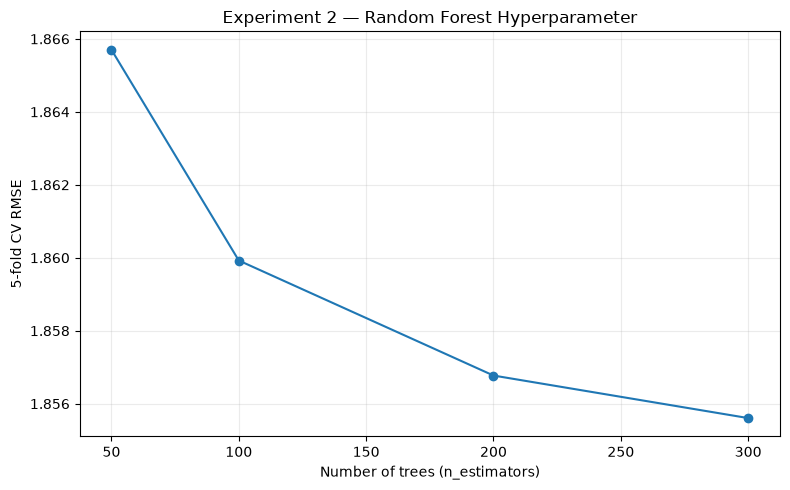

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(rf_tuning_df["n_estimators"], rf_tuning_df["CV_RMSE_mean"], marker="o")
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("5-fold CV RMSE")
plt.title("Experiment 2 — Random Forest Hyperparameter")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 16. Experiment 3 — Representation / Feature Investigation

**Câu hỏi:** Có cần các biến phân loại hay chỉ dùng biến số?

So sánh:
- **Representation A:** numeric-only;
- **Representation B:** numeric + categorical (baseline representation).

Mô hình dùng để kiểm tra là **Random Forest**, vì đây là mô hình mạnh và không yêu cầu giả định tuyến tính.


In [19]:
numeric_only = [c for c in numeric_cols if c in X_train.columns]

numeric_only_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_only)
    ],
    remainder="drop"
)

rf_numeric_only = Pipeline(steps=[
    ("preprocessor", numeric_only_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_all_features = pipelines["Random Forest"]

rep_scores = []
for rep_name, pipe in [
    ("Numeric only", rf_numeric_only),
    ("Numeric + Categorical", rf_all_features)
]:
    scores = cross_validate(
        pipe,
        X_train, y_train,
        cv=cv,
        scoring={
            "RMSE": "neg_root_mean_squared_error",
            "MAE": "neg_mean_absolute_error",
            "R2": "r2"
        },
        n_jobs=-1
    )
    rep_scores.append({
        "Representation": rep_name,
        "RMSE_mean": -scores["test_RMSE"].mean(),
        "MAE_mean": -scores["test_MAE"].mean(),
        "R2_mean": scores["test_R2"].mean()
    })

rep_df = pd.DataFrame(rep_scores).sort_values("RMSE_mean")
display(rep_df.style.format({
    "RMSE_mean": "{:.4f}",
    "MAE_mean": "{:.4f}",
    "R2_mean": "{:.4f}"
}))


,Representation,RMSE_mean,MAE_mean,R2_mean
1,Numeric + Categorical,1.8568,1.4451,0.2958
0,Numeric only,1.8976,1.4730,0.2645


## 17. Final Model

Sau khi hoàn thành controlled experiments, mô hình cuối cùng được huấn luyện trên **toàn bộ training set** với cấu hình đã chọn.

> Lưu ý: kết quả test bên dưới là đánh giá cuối cùng trên tập test chưa dùng trong cross-validation/hyperparameter selection.


In [20]:
# Nếu Random Forest là mô hình tốt nhất thì chọn cấu hình tốt nhất từ Experiment 2.
# Nếu mô hình khác thắng CV, dùng đúng pipeline của mô hình đó.
if best_model_name == "Random Forest":
    best_rf_n = int(rf_tuning_df.iloc[0]["n_estimators"])
    final_estimator = RandomForestRegressor(
        n_estimators=best_rf_n,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    final_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", final_estimator)
    ])
else:
    final_model = pipelines[best_model_name]

final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)

final_metrics = {
    "MAE": mean_absolute_error(y_test, test_pred),
    "MSE": mean_squared_error(y_test, test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "R2": r2_score(y_test, test_pred),
    "MAPE_%": mean_absolute_percentage_error(y_test, test_pred) * 100
}

final_results = pd.DataFrame([final_metrics], index=[best_model_name])
display(final_results.style.format("{:.4f}"))


,MAE,MSE,RMSE,R2,MAPE_%
Random Forest,1.4668,3.5666,1.8885,0.2685,33.0536


In [21]:
# So sánh cuối cùng với baseline trên cùng test set
comparison_test = pd.DataFrame([
    {
        "Model": "Baseline (Mean)",
        **baseline_metrics
    },
    {
        "Model": best_model_name,
        **final_metrics
    }
]).set_index("Model")

display(comparison_test.style.format({
    "MAE": "{:.4f}",
    "MSE": "{:.4f}",
    "RMSE": "{:.4f}",
    "R2": "{:.4f}",
    "MAPE": "{:.2f}",
    "MAPE_%": "{:.2f}"
}))


,MAE,MSE,RMSE,R2,MAPE,MAPE_%
Model,,,,,,
Baseline (Mean),1.8438,4.8760,2.2082,-0.0000,44.43,nan
Random Forest,1.4668,3.5666,1.8885,0.2685,nan,33.05


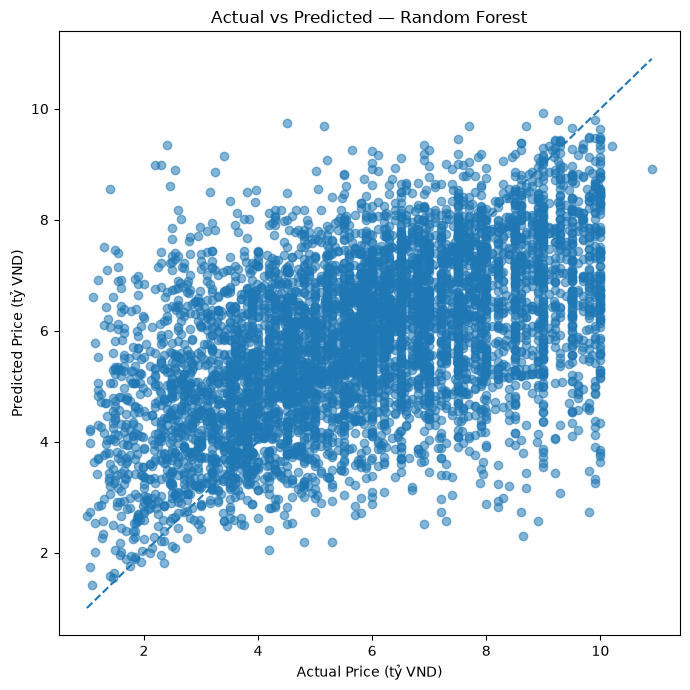

In [22]:
# Actual vs Predicted — kiểm tra trực quan mô hình cuối
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_pred, alpha=0.55)
lims = [
    min(float(y_test.min()), float(test_pred.min())),
    max(float(y_test.max()), float(test_pred.max()))
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual Price (tỷ VND)")
plt.ylabel("Predicted Price (tỷ VND)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.tight_layout()
plt.show()


## 18. Error Analysis

Không chỉ nhìn vào một con số metric, cần kiểm tra sai số dự đoán và các trường hợp có lỗi lớn.


In [23]:
error_df = X_test.copy()
error_df["Actual_Price"] = y_test.values
error_df["Predicted_Price"] = test_pred
error_df["Absolute_Error"] = np.abs(error_df["Actual_Price"] - error_df["Predicted_Price"])
error_df["Absolute_Percent_Error_%"] = (
    error_df["Absolute_Error"] / np.maximum(np.abs(error_df["Actual_Price"]), 1e-8) * 100
)

display(
    error_df.sort_values("Absolute_Error", ascending=False)
    .head(10)
)


,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,House direction,Balcony direction,Legal status,Furniture state,Actual_Price,Predicted_Price,Absolute_Error,Absolute_Percent_Error_%
22703,167.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Have certificate,NaN,1.40,8.549416,7.149416,510.672555
23432,73.0,8.25,4.0,1.0,2.0,1.0,NaN,NaN,Have certificate,NaN,9.80,2.737833,7.062167,72.062925
13049,80.0,NaN,NaN,3.0,4.0,4.0,NaN,NaN,Have certificate,NaN,2.40,9.352484,6.952484,289.686828
25430,131.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Have certificate,NaN,2.20,8.983196,6.783196,308.327104
13132,90.0,NaN,20.0,3.0,4.0,4.0,NaN,NaN,Have certificate,Full,2.30,8.984833,6.684833,290.644928
15980,45.0,4.00,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.90,3.260392,6.639608,67.066751
4667,80.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,Have certificate,Basic,9.90,3.322925,6.577075,66.435105
6717,100.0,NaN,NaN,3.0,4.0,4.0,Đông,NaN,NaN,NaN,10.00,3.626865,6.373135,63.731352
29146,85.0,NaN,NaN,2.0,3.0,2.0,NaN,NaN,Have certificate,Full,8.65,2.295322,6.354678,73.464483
8768,100.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,Sale contract,Basic,9.80,3.461662,6.338338,64.676923


## 19. Application — Inference Pipeline

Hàm dưới đây mô phỏng đúng đường đi:

**User Input → Feature Representation → Preprocessing → Model → Prediction**

Ứng dụng nhận một dictionary giống form nhập liệu. Vì pipeline đã chứa preprocessing, dữ liệu mới được xử lý giống dữ liệu training.


In [24]:
def predict_house_price(sample: dict) -> float:
    """Predict house price in billion VND for one new property."""
    sample_df = pd.DataFrame([sample])

    # Đảm bảo có đúng các feature model cần.
    for col in feature_cols:
        if col not in sample_df.columns:
            sample_df[col] = np.nan

    sample_df = sample_df[feature_cols]
    prediction = final_model.predict(sample_df)[0]
    return float(prediction)


# Case demo 1 — thay giá trị bằng giá trị hợp lệ trong dataset nếu cần
demo_case_1 = {c: np.nan for c in feature_cols}
for c, v in {
    "Area": 80,
    "Frontage": 5,
    "Access Road": 6,
    "Floors": 4,
    "Bedrooms": 3,
    "Bathrooms": 3,
}.items():
    if c in demo_case_1:
        demo_case_1[c] = v

demo_case_1


{'Area': 80,
 'Frontage': 5,
 'Access Road': 6,
 'Floors': 4,
 'Bedrooms': 3,
 'Bathrooms': 3,
 'House direction': nan,
 'Balcony direction': nan,
 'Legal status': nan,
 'Furniture state': nan}

In [25]:
# Ba input cases để đáp ứng yêu cầu system demonstration.
demo_cases = [
    demo_case_1,
    {**demo_case_1, **{k: v for k, v in {"Area": 50, "Floors": 3, "Bedrooms": 2, "Bathrooms": 2}.items() if k in feature_cols}},
    {**demo_case_1, **{k: v for k, v in {"Area": 150, "Floors": 5, "Bedrooms": 5, "Bathrooms": 4}.items() if k in feature_cols}},
]

demo_output = []
for i, case in enumerate(demo_cases, 1):
    pred = predict_house_price(case)
    demo_output.append({"Case": i, "Predicted Price (tỷ VND)": pred})

display(pd.DataFrame(demo_output).style.format({
    "Predicted Price (tỷ VND)": "{:.3f}"
}))


,Case,Predicted Price (tỷ VND)
0,1,7.731
1,2,5.225
2,3,8.257


## 20. Model Persistence

Lưu **toàn bộ pipeline** thay vì chỉ lưu estimator. Đây là điểm quan trọng để khi triển khai, input mới đi qua đúng preprocessing/encoding như lúc training.

File `.joblib` có thể được dùng làm artifact cho backend hoặc bước chuyển đổi Mobile ở giai đoạn sau.


In [26]:
import joblib
MODEL_PATH = "vietnam_house_price_model.joblib"

joblib.dump(
    {
        "model": final_model,
        "feature_cols": feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "target": TARGET,
        "metrics": final_metrics,
        "random_state": RANDOM_STATE
    },
    MODEL_PATH
)

print("Saved:", MODEL_PATH)


Saved: vietnam_house_price_model.joblib


## 21. Mobile Deployment — DEFER

**Trạng thái: DEFER theo yêu cầu.**

Notebook hiện hoàn thành phần ML và chuẩn bị artifact. Khi triển khai Mobile, kiến trúc đề xuất:

```text
Mobile UI
   ↓
Input validation
   ↓
Feature vector
   ↓
Model runtime
   ↓
Prediction
   ↓
Format giá (tỷ VND / VND)
```

Có hai hướng:
1. **On-device:** chuyển mô hình sang định dạng runtime phù hợp với Android/iOS (ví dụ ONNX/TFLite tùy mô hình được chọn và khả năng hỗ trợ operator).
2. **API backend:** Mobile gửi feature vector đến server, server chạy pipeline `.joblib` và trả giá dự đoán.

Ở giai đoạn này **không thực hiện chuyển đổi mobile runtime**, vì phần triển khai mobile đã được đánh dấu `defer`.


## 22. Reflection — What Makes This an Intelligent System?

1. **Thông tin nhận vào:** thuộc tính của bất động sản.
2. **Biểu diễn nội bộ:** vector đặc trưng numerical + categorical đã mã hóa.
3. **Model học gì:** quan hệ giữa các đặc trưng và `Price` từ các ví dụ huấn luyện.
4. **Prediction:** giá dự đoán cho một listing mới.
5. **Vì sao xử lý được unseen input:** mô hình học quy luật từ nhiều observations và tổng quát hóa; `OneHotEncoder(handle_unknown="ignore")` giúp category mới không gây lỗi pipeline.
6. **Phần được gọi là intelligent:** khả năng học từ dữ liệu và tạo dự đoán cho trường hợp chưa thấy.
7. **Hạn chế:** dữ liệu listing có thể có nhiễu/outlier; giá chịu ảnh hưởng của nhiều yếu tố chưa được biểu diễn; `Address` chưa được khai thác trực tiếp; mô hình không thể đảm bảo giá thị trường thực tế.

### Reflection on Representation

- Representation vector phù hợp với structured data.
- Giữ lại các đặc trưng vật lý và thuộc tính phân loại có trong dataset.
- Có thể mất thông tin địa lý chi tiết khi không đưa `Address` thô vào mô hình.
- Nếu biểu diễn thành **image/sequence/graph/embedding**, loại mô hình và quy trình learning sẽ thay đổi.


## 23. Conclusion

Notebook đã xây dựng một hệ thống nhỏ theo pipeline:

**Real-world data → Feature representation → Traditional ML → Prediction → Application**

Các yêu cầu chính đã được đáp ứng:
- Dataset thực từ Kaggle.
- 3 biểu đồ phân phối.
- 5 mô hình regression.
- 5 độ đo: MAE, MSE, RMSE, R², MAPE.
- Baseline.
- 3 controlled experiments.
- Chọn mô hình theo CV RMSE.
- Đánh giá cuối trên test set.
- 3 input cases cho application demonstration.
- Lưu pipeline model.
- Mobile deployment được đánh dấu **DEFER**.


## 24. Reproducibility Checklist

- Python + package versions được in ở đầu notebook.
- `random_state=42`.
- Dataset path được khai báo rõ ràng.
- Train/test split 80/20.
- Cross-validation chỉ dùng training set.
- Test set chỉ dùng cho đánh giá cuối.
- Preprocessing được đóng gói trong Pipeline.
- Model artifact được lưu bằng `joblib`.
